# Navier-Stokes (BFS outlet-profile) benchmark: adaptive delayed-acceptance MCMC vs. baselines

A backward-facing-step (BFS) incompressible flow, solved with a FEniCSx IPCS-like
splitting scheme (`solver_hf.py`). The unknowns are `theta = [h1, U_in, L_down]`
(upstream channel height, inlet velocity, downstream channel length; `h2`/`L_up` held
fixed), inferred from a noisy observed outlet velocity profile `u_x(y)`.

**Four inference strategies** (the comparison harness lives in
`gp_active_mcmc.verification`; only the physics/problem setup is specific to this
example, in `solver_hf.py`/`ns_methods.py` -- see `examples/toy_problem/msd_benchmark.ipynb`
for the paper's full write-up of these four strategies, which applies unchanged here):

1. **HF-only Metropolis-Hastings** -- ground-truth reference; every step calls the
   expensive FEM solve.
2. **Pretrained** -- a POD-GP surrogate trained offline via greedy max-variance active
   learning, then frozen and used as if exact.
3. **Adaptive surrogate MCMC** (`adaptive_surrogate_mcmc`, Riccius, synced) -- the
   surrogate is substituted for the likelihood and refined online via an uncertainty
   threshold, with no delayed-acceptance (DA) correction; every replicate's
   individually-collected HF points are additionally pooled into a shared surrogate
   each round.
4. **Adaptive STM** (`adaptive_stm`, ours) -- the surrogate is refined online during an
   adaptive phase, guided by the MCMC path; once its accuracy stabilizes it is frozen
   and a delayed-acceptance chain generates the production samples.

**Status.** Unlike the MSD benchmark, this one has not actually been run: `solver_hf.py`
requires the Navier-Stokes/FEniCSx stack (`dolfinx`, `mpi4py`, `petsc4py`, `basix`),
which this repository does not install as a dependency. `ns_methods.py`'s calibrated
constants (`N_INIT`, `GAMMA_THRESHOLD`, ...) are therefore illustrative -- scaled down
from MSD's own numbers to reflect that each HF evaluation here is a real FEM solve --
not tuned by a real sweep. This notebook is the intended entry point once that sweep
has been run (`run.py --n-seeds 25`, mirroring `examples/toy_problem/run.py` exactly);
until then, the cells below that load `results/sweep_convergence_driven.jsonl` will
report that no data is available yet, and the "Problem setup" cell is the only one
that actually executes something (a single HF forward solve).


### Methods and naming

Every problem-agnostic piece of the comparison (`run_hf_only`, `run_pretrained`,
`run_adaptive_stm`, `run_convergence_driven_comparison`, the R-hat-driven multi-chain
round loop, the W2/KL/pooled-summary metrics) lives in `gp_active_mcmc.verification`,
tested and shared with `examples/toy_problem/`; only the physics/problem setup
(`Problem`, `build_problem`, this problem's calibrated constants) is defined locally in
`ns_methods.py`, mirroring `msd_methods.py`'s role exactly. `adaptive_surrogate_mcmc`
is built from `run_convergence_driven_comparison`'s own orchestration rather than a
standalone `run_*` function, for the same reason as on the MSD side: pooling every
replicate's HF points into a shared surrogate each round is a property of the
multi-chain loop, not a single-chain method.

`backward.py` and `forward.py` are separate, standalone single-run tutorials (an
Active-MCMC/Adaptive-DA-MCMC walkthrough and a surrogate-accuracy report,
respectively) and are independent of this notebook and `run.py` -- they hand-roll
their own MCMC/surrogate wiring for pedagogical purposes rather than going through
`gp_active_mcmc.verification`.


In [ ]:
from __future__ import annotations

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from ns_methods import PARAM_NAMES, RESULTS_DIR, build_problem
from ns_plots import plot_accuracy_boxplots, plot_training_cost_boxplot

FIGURES_DIR = RESULTS_DIR / "figures/"
SWEEP_PATH = RESULTS_DIR / "sweep_convergence_driven.jsonl"

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


/Users/filippozacchei/COde/MFDA_ActiveLearning/examples/navier_stokes/solver_hf.py:7: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  import tqdm.autonotebook
2026-09-07 22:01:38,186	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## Problem setup

One example problem instance: `theta_true` drawn from the prior, and a noisy
synthetic observation of the resulting outlet velocity profile. This is the one cell
in this notebook that runs a real HF solve, so it requires the FEniCSx stack.


theta_true: {'h1': 0.10800528313054103, 'U_in': 1.0157162776366742, 'L_down': 0.39669737841771746}


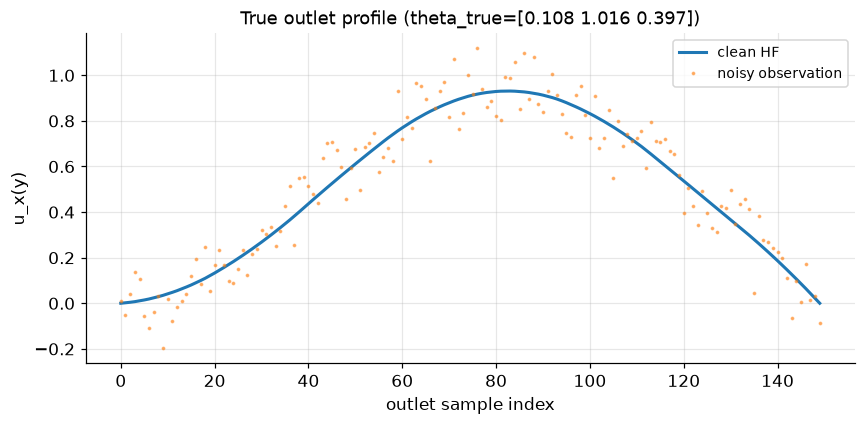

In [ ]:
problem = build_problem(problem_seed=0, sigma_obs=0.1)
print("theta_true:", dict(zip(PARAM_NAMES, problem.theta_true.tolist(), strict=True)))

y_idx = np.arange(problem.y_obs.shape[0])  # NS has no problem.t; index along the resampled outlet line
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(y_idx, problem.hf_forward(problem.theta_true), lw=2, label="clean HF")
ax.plot(y_idx, problem.y_obs, ".", ms=3, alpha=0.5, label="noisy observation")
ax.set_xlabel("outlet sample index")
ax.set_ylabel("u_x(y)")
ax.legend()
ax.set_title(f"True outlet profile (theta_true={np.round(problem.theta_true, 3)})")
fig.tight_layout()


## Running the comparison

`run.py --n-seeds 25` runs both comparisons (training cost and posterior accuracy)
for 25 independent problem instances (fresh `theta_true`/observation and offline seed
design each) and saves per-seed metrics to `results/sweep_convergence_driven.jsonl`
and per-seed figures to `results/figures/`. This notebook loads and aggregates that
output, mirroring `msd_benchmark.ipynb` exactly. See `run.py --help` for every knob
(`--tag` to keep multiple sweeps side by side, `--skip-training-cost` for a faster
posterior-only run, ...).


In [ ]:
if not SWEEP_PATH.exists():
    print(f"{SWEEP_PATH} not found -- run `python run.py --n-seeds 25` first.")
    sweep_rows = []
else:
    sweep_rows = [json.loads(line) for line in SWEEP_PATH.read_text().splitlines() if line.strip()]
    print(f"Loaded {len(sweep_rows)} seed(s) from {SWEEP_PATH}")


Loaded 25 seed(s) from /Users/filippozacchei/COde/MFDA_ActiveLearning/examples/navier_stokes/results/sweep_convergence_driven.jsonl


## Example: surrogate fit and posterior (seed 0)

One example from the sweep: the trained surrogate's prediction at `theta_true` for
each method (top), and the pooled posterior for
`hf_only`/`adaptive_surrogate_mcmc`/`adaptive_stm` (bottom, first two of the three
parameters), each pooled across its replicate chains at its own R-hat-validated
burn-in. The same figures are saved for every seed in `results/figures/`.


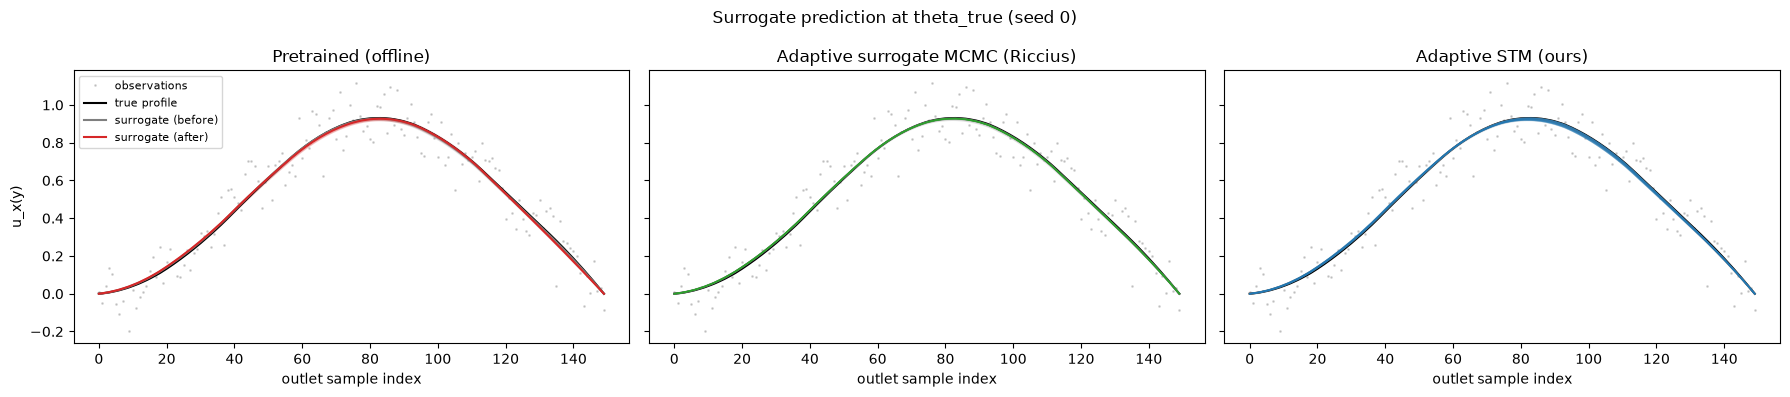

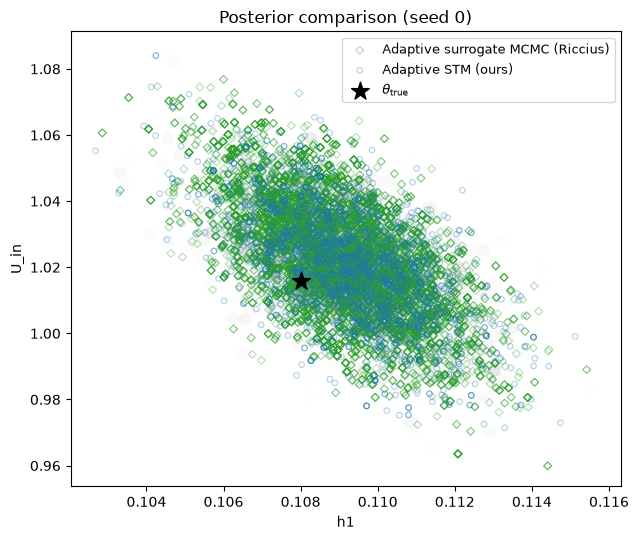

In [ ]:
example_seed = sweep_rows[0]["seed"] if sweep_rows else 0
display(Image(filename=str(FIGURES_DIR / f"surrogate_comparison_seed_{example_seed}.png")))
display(Image(filename=str(FIGURES_DIR / f"posterior_scatter_seed_{example_seed}.png")))


## Training-cost comparison

Extra HF evaluations beyond the shared offline seed design -- `adaptive_stm`'s online
adaptive phase vs. `pretrained`'s offline active-learning procedure -- across all
seeds.


        offline_extra_hf  online_extra_hf
mean           122.00000        57.200000
median          75.00000        55.000000
std            117.99541         9.092121

adaptive_stm's adaptive-phase convergence rate: 100.0%


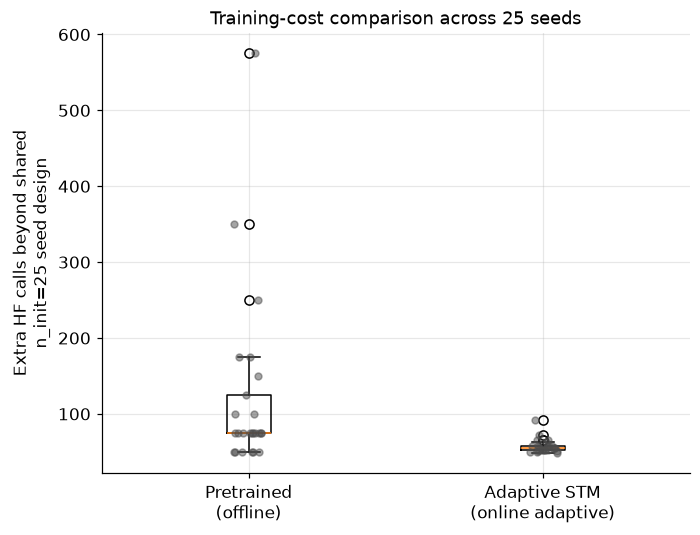

In [ ]:
tc_rows = [r for r in sweep_rows if r["training_cost"] is not None]
if not tc_rows:
    print(
        f"No training-cost data in these {len(sweep_rows)} seed(s) -- this sweep was run with "
        "--skip-training-cost. Rerun without that flag to populate this section."
    )
else:
    if len(tc_rows) < len(sweep_rows):
        print(f"Note: only {len(tc_rows)}/{len(sweep_rows)} seed(s) have training-cost data; the rest were "
              "presumably run with --skip-training-cost and are excluded below.")

    tc_df = pd.DataFrame([
        {
            "seed": r["seed"],
            "offline_extra_hf": r["training_cost"]["offline"]["n_hf_extra"],
            "online_extra_hf": r["training_cost"]["online"]["n_hf_extra"],
            "online_converged": r["training_cost"]["online"]["converged"],
        }
        for r in tc_rows
    ])
    print(tc_df[["offline_extra_hf", "online_extra_hf"]].agg(["mean", "median", "std"]))
    print(f"\nadaptive_stm's adaptive-phase convergence rate: {tc_df['online_converged'].mean():.1%}")

    fig = plot_training_cost_boxplot(
        tc_df["offline_extra_hf"].to_numpy(), tc_df["online_extra_hf"].to_numpy(), n_init=tc_rows[0]["n_init"]
    )
    fig.savefig(FIGURES_DIR / "training_cost_sweep.png", bbox_inches="tight")


## Posterior-accuracy comparison

Cost to reach R-hat<=1.01 across replicate chains, and distributional distance
(Wasserstein-2, KL) to the `hf_only` reference posterior, across all seeds.


method
adaptive_stm               0.92
adaptive_surrogate_mcmc    0.88
hf_only                    1.00
Name: convergence_rate, dtype: float64

                        total_coarse_evals                      n_hf_calls  \
                                      mean  median          std       mean   
method                                                                       
adaptive_stm                        9900.0  7150.0  7889.391612     2010.0   
adaptive_surrogate_mcmc             6604.0  2850.0  9077.237098       62.6   
hf_only                             3330.0  2750.0  1326.571395    16655.0   

                                                 w2_ref                      \
                          median          std      mean    median       std   
method                                                                        
adaptive_stm              1460.0  1577.878322  0.002334  0.001781  0.001818   
adaptive_surrogate_mcmc     54.0    26.470109  0.008607  0.004202  0.018

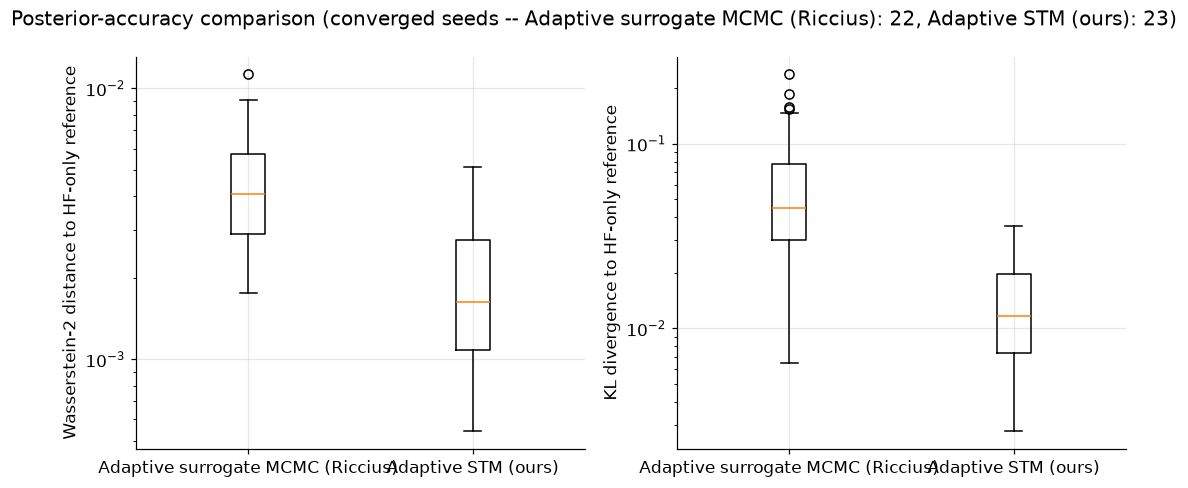

In [ ]:
candidate_methods = ("hf_only", "adaptive_surrogate_mcmc", "adaptive_stm")

pa_rows = []
for r in sweep_rows:
    for method in candidate_methods:
        p = r["posterior"].get(method)
        if p is None:
            continue
        pooled = p.get("pooled", {})
        pa_rows.append({
            "seed": r["seed"],
            "method": method,
            "converged": p["converged"],
            "total_coarse_evals": p["total_coarse_evals"],
            "n_hf_calls": pooled.get("n_hf_calls"),
            "w2_ref": pooled.get("wasserstein2_to_reference"),
            "kl_ref": pooled.get("kl_to_reference"),
            "rmse": pooled.get("rmse_to_truth"),
        })
pa_df = pd.DataFrame(pa_rows)
print(pa_df.groupby("method")["converged"].mean().rename("convergence_rate"))
print()
print(pa_df.groupby("method")[["total_coarse_evals", "n_hf_calls", "w2_ref", "kl_ref", "rmse"]].agg(["mean", "median", "std"]))

method_order = ("adaptive_surrogate_mcmc", "adaptive_stm")
converged = pa_df[pa_df["converged"]]
w2_by_method = {m: converged.loc[converged["method"] == m, "w2_ref"].dropna().to_numpy() for m in method_order}
kl_by_method = {m: converged.loc[converged["method"] == m, "kl_ref"].dropna().to_numpy() for m in method_order}

fig = plot_accuracy_boxplots(w2_by_method, kl_by_method, method_order=method_order)
fig.savefig(FIGURES_DIR / "posterior_accuracy_sweep.png", bbox_inches="tight")
